# PIONEER Phase-I $R_{e/\mu}$ Measurement Strategy Figures

This notebook generates dissertation-ready pedagogical figures for explaining the Phase-I PIONEER $R_{e/\mu}$ measurement strategy. The plots are intentionally illustrative and self-contained; they are not detector simulation and do not include shower leakage, photonuclear effects, radiative corrections, geometry, pileup, triggering, or reconstruction effects.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch

# Constants in MeV and ns. These figures are pedagogical, not detector simulation.
m_pi = 139.57039
m_mu = 105.65837
m_e = 0.51099895

E_pi_to_e = (m_pi**2 + m_e**2) / (2 * m_pi)
K_pi_to_e = E_pi_to_e - m_e
E_michel_max = (m_mu**2 + m_e**2) / (2 * m_mu)

tau_pi_ns = 26.033
tau_mu_ns = 2196.9811
E_cut = 56.0

rng = np.random.default_rng(20260211)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

OUTDIR = PROJECT_ROOT / "resources" / "figures" / "generated" / "measurement_strategy"
OUTDIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.linewidth": 1.2,
    "lines.linewidth": 2.3,
    "mathtext.fontset": "stix",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

COLOR_MICHEL = "#2F6FBB"
COLOR_PI_E = "#D95F02"
COLOR_CUT = "#222222"
COLOR_MU = "#7B3294"

def savefig(name, fig=None):
    """Save a figure as PDF and PNG using dissertation-friendly settings."""
    if fig is None:
        fig = plt.gcf()
    pdf_path = OUTDIR / f"{name}.pdf"
    png_path = OUTDIR / f"{name}.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, bbox_inches="tight")
    print(f"saved {pdf_path.relative_to(PROJECT_ROOT)}")
    print(f"saved {png_path.relative_to(PROJECT_ROOT)}")

def michel_pdf(E):
    """Massless-electron Michel shape for an unpolarized muon at rest."""
    E = np.asarray(E)
    x = E / E_michel_max
    y = np.zeros_like(x, dtype=float)
    mask = (x >= 0) & (x <= 1)
    y[mask] = x[mask]**2 * (3 - 2 * x[mask])
    return y

def sample_michel(n, rng):
    """Sample the Michel shape by rejection sampling."""
    samples = []
    remaining = n
    while remaining > 0:
        proposal = rng.random(max(remaining * 2, 10_000))
        accept = rng.random(proposal.size) < proposal**2 * (3 - 2 * proposal)
        accepted = proposal[accept]
        samples.append(accepted[:remaining])
        remaining -= min(remaining, accepted.size)
    return E_michel_max * np.concatenate(samples)

def smear_energy(E, resolution_fraction, rng):
    """Apply illustrative Gaussian calorimeter smearing, sigma_E = r E."""
    E = np.asarray(E)
    sigma = resolution_fraction * E
    return rng.normal(E, sigma)

print(f"E(pi+ -> e+ nu_e), total positron energy = {E_pi_to_e:.3f} MeV")
print(f"K(pi+ -> e+ nu_e), positron kinetic energy = {K_pi_to_e:.3f} MeV")
print(f"Michel endpoint = {E_michel_max:.3f} MeV")
print(f"E_cut = {E_cut:.1f} MeV")
print(f"tau_pi = {tau_pi_ns:.3f} ns")
print(f"tau_mu = {tau_mu_ns:.4f} ns")

E(pi+ -> e+ nu_e), total positron energy = 69.786 MeV
K(pi+ -> e+ nu_e), positron kinetic energy = 69.275 MeV
Michel endpoint = 52.830 MeV
E_cut = 56.0 MeV
tau_pi = 26.033 ns
tau_mu = 2196.9811 ns


## Figure 1: Ideal Positron Energy Spectra

This figure supports the basic counting argument: the sequential pion decay chain produces a high-rate Michel spectrum below the endpoint, while direct pion decay produces a much rarer monoenergetic positron peak. The log scale makes the approximate $10^{-4}$ relative scale visible while keeping the analysis threshold and the $N_L$/$N_H$ regions clear.

saved resources/figures/generated/measurement_strategy/ideal_positron_energy_spectra.pdf
saved resources/figures/generated/measurement_strategy/ideal_positron_energy_spectra.png


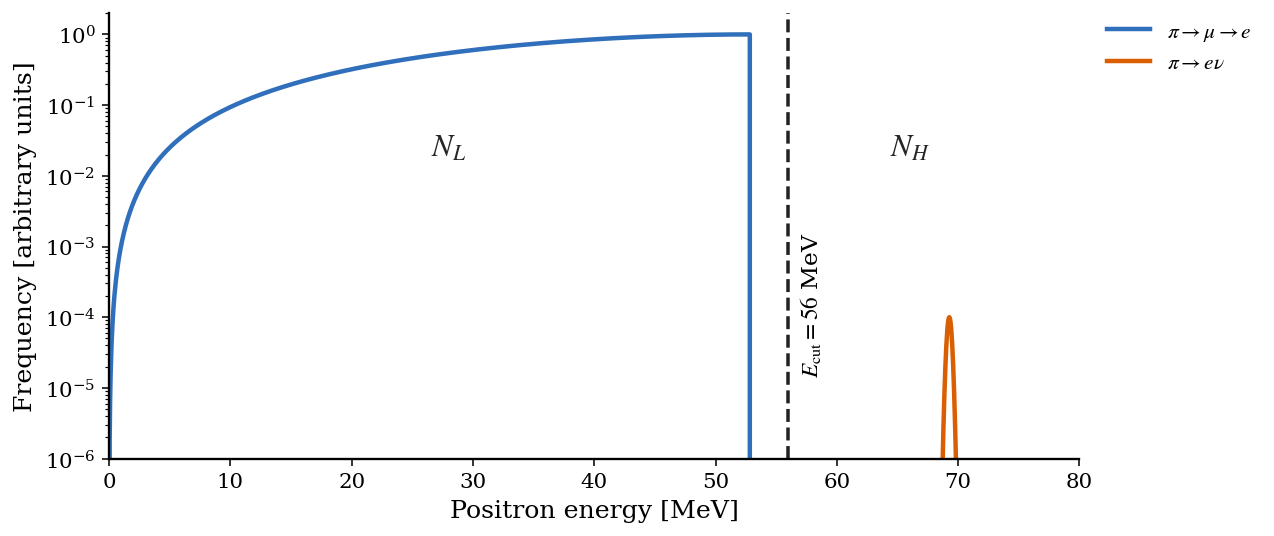

In [2]:
E = np.linspace(0, 80, 2000)
michel = michel_pdf(E)
michel /= michel.max()

# A very narrow Gaussian is used only to make the monoenergetic line visible.
sigma_line = 0.18
pi_line = np.exp(-0.5 * ((E - K_pi_to_e) / sigma_line)**2)
pi_line = 1.0e-4 * pi_line / pi_line.max()

fig = plt.figure(figsize=(10.5, 4.3))
ax = fig.add_axes([0.09, 0.18, 0.66, 0.74])
ax.plot(E, michel, color=COLOR_MICHEL, label=r"$\pi\to\mu\to e$")
ax.plot(E, pi_line, color=COLOR_PI_E, label=r"$\pi\to e\nu$")
ax.axvline(E_cut, color=COLOR_CUT, ls="--", lw=1.8)

ax.text(28, 2.5e-2, r"$N_L$", ha="center", va="center", fontsize=16, color="0.15")
ax.text(66, 2.5e-2, r"$N_H$", ha="center", va="center", fontsize=16, color="0.15")
ax.text(E_cut + 0.8, 1.4e-5, r"$E_{\rm cut}=56$ MeV", rotation=90, va="bottom", ha="left")

ax.set_xlim(0, 80)
ax.set_yscale("log")
ax.set_ylim(1.0e-6, 2.0)
ax.set_xlabel("Positron energy [MeV]")
ax.set_ylabel("Frequency [arbitrary units]")
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)
ax.spines[["top", "right"]].set_visible(False)
savefig("ideal_positron_energy_spectra", fig)
plt.show()

## Figure 2: Positron Tail Leakage Below the Energy Cut

This figure illustrates why the $\pi\to e\nu$ calorimeter response must be corrected. A small low-energy tail of true direct-pion-decay positrons can fall below $E_{\rm cut}$ and be counted in the low-energy sample unless it is measured or constrained. The shape is pedagogical and is not detector simulation; the active target helps identify and suppress the underlying event-classification ambiguities.

saved resources/figures/generated/measurement_strategy/positron_tail_correction.pdf
saved resources/figures/generated/measurement_strategy/positron_tail_correction.png


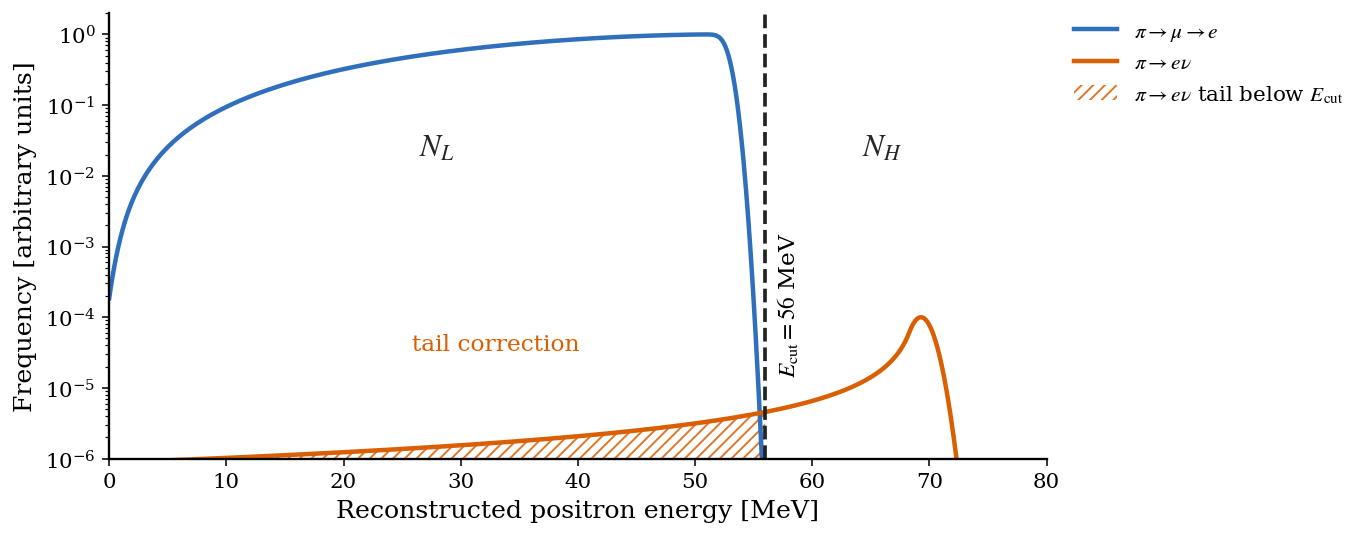

In [18]:
E = np.linspace(0, 80, 2500)

# Ideal Michel spectrum
michel = michel_pdf(E)

# Add mild illustrative detector smearing to soften the Michel endpoint.
# This is pedagogical only and not a detector simulation.
michel_sigma = 0.6  # MeV

dE = E[1] - E[0]
kernel_x = np.arange(-6 * michel_sigma, 6 * michel_sigma + dE, dE)

kernel = np.exp(-0.5 * (kernel_x / michel_sigma) ** 2)
kernel /= kernel.sum()

michel = np.convolve(michel, kernel, mode="same")
michel /= michel.max()

# Left-sided Crystal Ball response for true pi -> e nu events.
# Pedagogical only; not detector simulation.

def left_crystal_ball(E, peak, sigma, alpha, n):
    t = (E - peak) / sigma

    A = (n / alpha) ** n * np.exp(-0.5 * alpha**2)
    B = n / alpha - alpha

    y = np.empty_like(t)
    core = t > -alpha

    y[core] = np.exp(-0.5 * t[core] ** 2)
    y[~core] = A * (B - t[~core]) ** (-n)

    return y

peak = K_pi_to_e
sigma = 1
alpha = 1
n = 1

pi_response = left_crystal_ball(E, peak, sigma, alpha, n)
pi_response = 1.0e-4 * pi_response / pi_response.max()

fig = plt.figure(figsize=(10.8, 4.3))
ax = fig.add_axes([0.09, 0.18, 0.62, 0.74])
ax.plot(
    E,
    michel,
    color=COLOR_MICHEL,
    label=r"$\pi\to\mu\to e$",
)
ax.plot(E, pi_response, color=COLOR_PI_E, label=r"$\pi\to e\nu$")
ax.axvline(E_cut, color=COLOR_CUT, ls="--", lw=1.9)

tail_mask = E <= E_cut
ax.fill_between(
    E[tail_mask],
    1.0e-6,
    pi_response[tail_mask],
    where=pi_response[tail_mask] > 1.0e-6,
    facecolor="none",
    edgecolor=COLOR_PI_E,
    hatch="////",
    linewidth=0.0,
    alpha=0.85,
    label=r"$\pi\to e\nu$ tail below $E_{\rm cut}$",
)

ax.text(28, 2.5e-2, r"$N_L$", ha="center", va="center", fontsize=16, color="0.15")
ax.text(66, 2.5e-2, r"$N_H$", ha="center", va="center", fontsize=16, color="0.15")
ax.text(33, 4.2e-5, "tail correction", ha="center", va="center", color=COLOR_PI_E)
ax.text(E_cut + 0.8, 1.4e-5, r"$E_{\rm cut}=56$ MeV", rotation=90, va="bottom", ha="left")

ax.set_xlim(0, 80)
ax.set_yscale("log")
ax.set_ylim(1.0e-6, 2.0)
ax.set_xlabel("Reconstructed positron energy [MeV]")
ax.set_ylabel("Frequency [arbitrary units]")
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)
ax.spines[["top", "right"]].set_visible(False)
savefig("positron_tail_correction", fig)
plt.show()

## Figure 3: Timing Separation

These figures compare the prompt pion decay-time distribution with the delayed muon decay-time distribution. The short time view emphasizes prompt $\pi\to e\nu$ decays, while the long time view shows the scale of the muon lifetime.

saved resources/figures/generated/measurement_strategy/timing_separation_prompt_view.pdf
saved resources/figures/generated/measurement_strategy/timing_separation_prompt_view.png


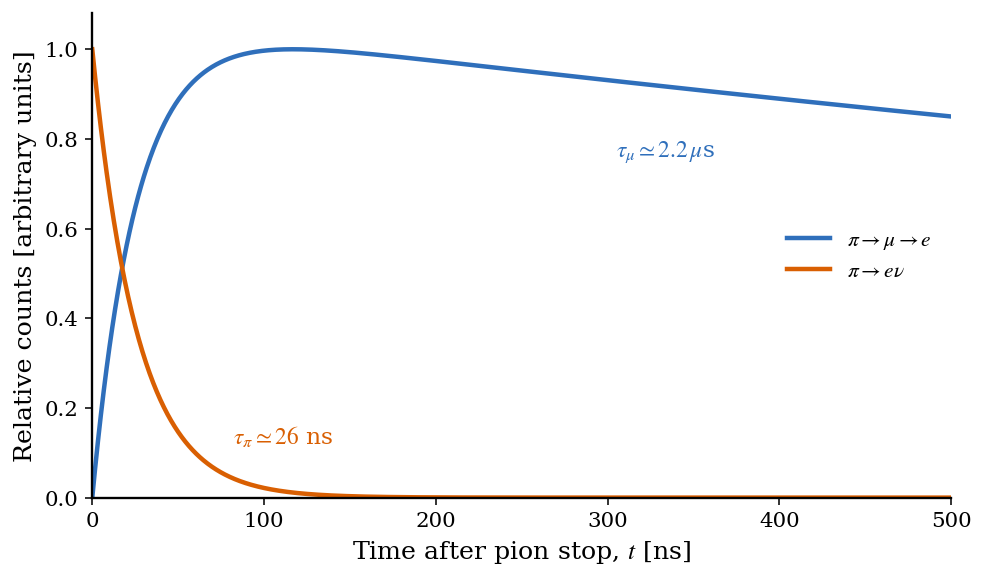

saved resources/figures/generated/measurement_strategy/timing_separation_long_view.pdf
saved resources/figures/generated/measurement_strategy/timing_separation_long_view.png


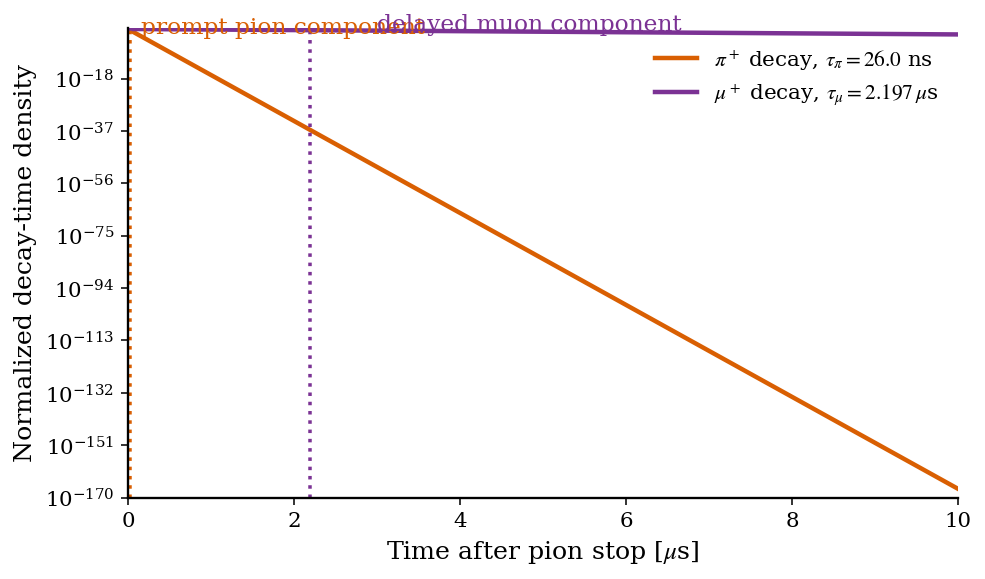

In [4]:
def exponential_pdf(t, tau):
    return np.exp(-t / tau) / tau

def sequential_pion_muon_pdf(t, tau_pi, tau_mu):
    """Decay-time shape for pi -> mu -> e, ignoring detector effects."""
    return (np.exp(-t / tau_mu) - np.exp(-t / tau_pi)) / (tau_mu - tau_pi)

t_prompt = np.linspace(0, 500, 1200)
pi_prompt = np.exp(-t_prompt / tau_pi_ns)
sequential_prompt = sequential_pion_muon_pdf(t_prompt, tau_pi_ns, tau_mu_ns)
pi_prompt /= pi_prompt.max()
sequential_prompt /= sequential_prompt.max()

fig, ax = plt.subplots(figsize=(7.2, 4.3))
ax.plot(t_prompt, sequential_prompt, color=COLOR_MICHEL, label=r"$\pi\to\mu\to e$")
ax.plot(t_prompt, pi_prompt, color=COLOR_PI_E, label=r"$\pi\to e\nu$")
ax.text(82, 0.12, rf"$\tau_\pi\simeq{tau_pi_ns:.0f}$ ns", color=COLOR_PI_E)
ax.text(305, 0.76, r"$\tau_\mu\simeq2.2\,\mu$s", color=COLOR_MICHEL)
ax.set_xlim(0, 500)
ax.set_ylim(0, 1.08)
ax.set_xlabel(r"Time after pion stop, $t$ [ns]")
ax.set_ylabel("Relative counts [arbitrary units]")
ax.legend(frameon=False, loc="center right")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
savefig("timing_separation_prompt_view", fig)
plt.show()

t_long = np.linspace(0, 10_000, 1600)
pi_long = exponential_pdf(t_long, tau_pi_ns)
mu_long = exponential_pdf(t_long, tau_mu_ns)

fig, ax = plt.subplots(figsize=(7.2, 4.3))
ax.semilogy(t_long / 1000, pi_long / pi_long.max(), color=COLOR_PI_E, label=rf"$\pi^+$ decay, $\tau_\pi={tau_pi_ns:.1f}$ ns")
ax.semilogy(t_long / 1000, mu_long / mu_long.max(), color=COLOR_MU, label=rf"$\mu^+$ decay, $\tau_\mu=2.197\,\mu$s")
ax.axvline(tau_pi_ns / 1000, color=COLOR_PI_E, ls=":", lw=1.8)
ax.axvline(tau_mu_ns / 1000, color=COLOR_MU, ls=":", lw=1.8)
ax.text(0.16, 2e-2, r"prompt pion component", color=COLOR_PI_E)
ax.text(3.0, 3e-1, r"delayed muon component", color=COLOR_MU)
ax.set_xlim(0, 10)
ax.set_ylim(1e-170, 2)
ax.set_xlabel(r"Time after pion stop [$\mu$s]")
ax.set_ylabel("Normalized decay-time density")
ax.legend(frameon=False, loc="upper right")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
savefig("timing_separation_long_view", fig)
plt.show()

## Figure 4: Simple Event Topology Schematic

This schematic illustrates the qualitative topology difference between a prompt direct pion decay and the sequential pion-to-muon-to-positron chain. It uses only Matplotlib primitives and is intended as a clean pedagogical diagram, not a detector rendering.

saved resources/figures/generated/measurement_strategy/event_topology_schematic.pdf
saved resources/figures/generated/measurement_strategy/event_topology_schematic.png


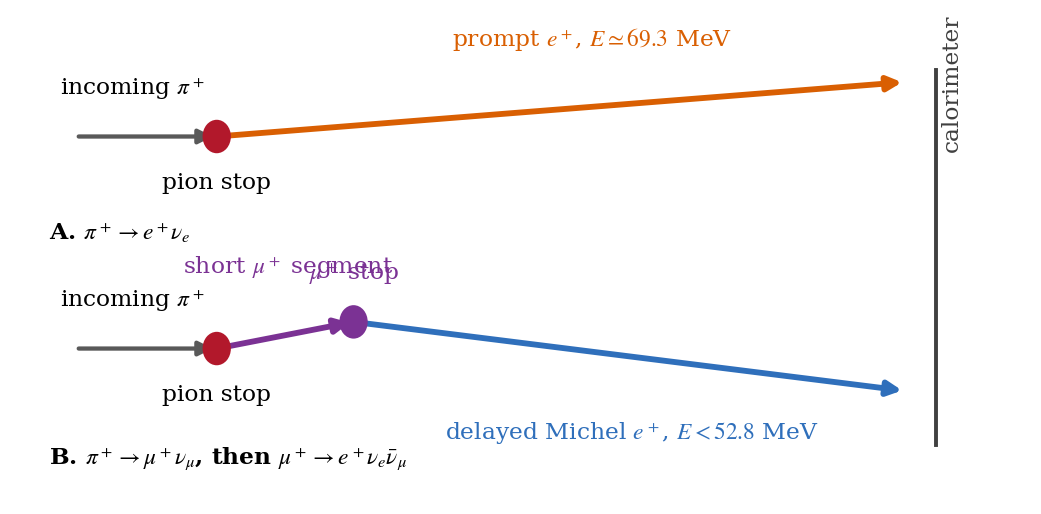

In [5]:
fig, ax = plt.subplots(figsize=(7.6, 3.9))
ax.set_xlim(0, 10)
ax.set_ylim(0, 4)
ax.axis("off")

def draw_arrow(start, end, color, lw=2.8, style="-"):
    arrow = FancyArrowPatch(
        start, end,
        arrowstyle="-|>",
        mutation_scale=15,
        linewidth=lw,
        linestyle=style,
        color=color,
        shrinkA=2,
        shrinkB=2,
    )
    ax.add_patch(arrow)

# Direct pion decay topology.
y_top = 3.0
pi_stop_top = (2.0, y_top)
ax.add_patch(Circle(pi_stop_top, 0.13, color="#B2182B", zorder=3))
draw_arrow((0.6, y_top), pi_stop_top, "0.35", lw=2.2)
draw_arrow(pi_stop_top, (8.8, y_top + 0.45), COLOR_PI_E, lw=3.0)
ax.text(0.45, y_top + 0.35, r"incoming $\pi^+$", ha="left")
ax.text(pi_stop_top[0], y_top - 0.43, "pion stop", ha="center")
ax.text(5.7, y_top + 0.75, r"prompt $e^+$, $E\simeq69.3$ MeV", ha="center", color=COLOR_PI_E)
ax.text(0.35, y_top - 0.85, r"A. $\pi^+\to e^+\nu_e$", ha="left", weight="bold")

# Sequential topology.
y_bot = 1.25
pi_stop_bot = (2.0, y_bot)
mu_stop = (3.35, y_bot + 0.22)
ax.add_patch(Circle(pi_stop_bot, 0.13, color="#B2182B", zorder=3))
ax.add_patch(Circle(mu_stop, 0.13, color=COLOR_MU, zorder=3))
draw_arrow((0.6, y_bot), pi_stop_bot, "0.35", lw=2.2)
draw_arrow(pi_stop_bot, mu_stop, COLOR_MU, lw=3.0)
draw_arrow(mu_stop, (8.8, y_bot - 0.35), COLOR_MICHEL, lw=3.0)
ax.text(0.45, y_bot + 0.35, r"incoming $\pi^+$", ha="left")
ax.text(pi_stop_bot[0], y_bot - 0.43, "pion stop", ha="center")
ax.text(mu_stop[0], mu_stop[1] + 0.35, r"$\mu^+$ stop", ha="center", color=COLOR_MU)
ax.text(6.1, y_bot - 0.75, r"delayed Michel $e^+$, $E<52.8$ MeV", ha="center", color=COLOR_MICHEL)
ax.text(2.7, y_bot + 0.62, r"short $\mu^+$ segment", ha="center", color=COLOR_MU)
ax.text(0.35, y_bot - 0.95, r"B. $\pi^+\to\mu^+\nu_\mu$, then $\mu^+\to e^+\nu_e\bar{\nu}_\mu$", ha="left", weight="bold")

ax.text(9.25, 3.45, "calorimeter", rotation=90, va="center", ha="center", color="0.25")
ax.plot([9.1, 9.1], [0.45, 3.55], color="0.25", lw=2.0)
fig.tight_layout()
savefig("event_topology_schematic", fig)
plt.show()

## Suggested LaTeX Captions

**Ideal positron energy spectra.** Idealized positron energy spectra for the two charged-pion decay channels relevant to the Phase-I $R_{e/\mu}$ measurement. Direct $\pi^+\to e^+\nu_e$ decay produces a monoenergetic positron near 69.3 MeV, while the sequential $\pi^+\to\mu^+\nu_\mu$ followed by $\mu^+\to e^+\nu_e\bar{\nu}_\mu$ decay produces a Michel spectrum ending near 52.8 MeV. The dashed line indicates an illustrative analysis threshold at $E_{\rm cut}=56$ MeV.

**Positron tail correction.** Pedagogical energy-spectrum illustration showing how a small low-energy tail of true $\pi\to e\nu$ positrons can fall below $E_{\rm cut}$ and contaminate the low-energy $N_L$ sample. The hatched region indicates events requiring a tail correction. The shape is illustrative and does not include detector simulation, shower leakage, photonuclear effects, radiative corrections, geometry, pileup, or reconstruction effects.

**Timing separation.** Prompt and delayed decay-time distributions for pion and muon decay. The direct $\pi\to e\nu$ channel follows the pion lifetime, $\tau_\pi=26.033$ ns, while the sequential $\pi\to\mu\to e$ channel is governed by the muon lifetime, $\tau_\mu=2.197\,\mu$s.

**Event topology schematic.** Pedagogical topology comparison between direct pion decay and the sequential pion-to-muon-to-positron chain in an active target. The direct decay produces a prompt high-energy positron from the pion stop, while the sequential channel contains a short muon segment, a muon stop, and a delayed Michel positron.